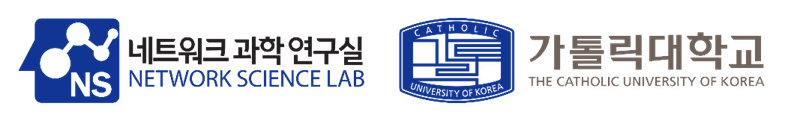

# Week 6: Homophily and Heterophily

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W6/SampleCode_6.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Do connected nodes share the same label?

* **Homophily**: *"birds of a feather flock together"*: edges mostly join nodes of the **same** class (papers cite papers on the same topic).
* **Heterophily**: *"opposites attract"*: edges mostly join nodes of **different** classes (students link to their professor's page, not to other students).

## Table of contents

- [1. Setup](#1-setup)
- [2. Real-world datasets](#2-real-world-datasets)
- [3. Four homophily metrics](#3-four-homophily-metrics)
- [4. Homophily of real-world graphs](#4-homophily-of-real-world-graphs)
- [4.1. Class compatibility matrix](#41-class-compatibility-matrix)
- [4.2. Node homophily is a distribution, not a number](#42-node-homophily-is-a-distribution-not-a-number)
- [5. Why do we need adjusted homophily?](#5-why-do-we-need-adjusted-homophily)
- [6. Why it matters: GCN vs. MLP](#6-why-it-matters-gcn-vs-mlp)
- [7. Takeaways](#7-takeaways)

## 1. Setup

In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])

In [2]:
import contextlib
import io
import tempfile
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Optional PyG extension notices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid, WebKB, WikipediaNetwork, Actor
from torch_geometric.nn import GCNConv
from torch_geometric.utils import degree, homophily, to_networkx

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

# One color per role, reused in every figure.
HOMO_COLOR, HETERO_COLOR = "#2a78d6", "#eb6834"
CLASS_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#8c6d46"]
CROSS_EDGE_COLOR = "#e34948"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print(f"torch {torch.__version__} | device: {DEVICE}")

torch 2.11.0+cu126 | device: cuda


## 2. Real-world datasets

| Group | Datasets | Nodes are … | Labels are … |
|:--|:--|:--|:--|
| Homophilous | **Cora, CiteSeer, PubMed** | scientific papers | research topic |
| Heterophilous | **Texas, Wisconsin, Cornell** (WebKB) | university web pages | student / faculty / course / … |
| Heterophilous | **Chameleon, Squirrel** (Wikipedia) | Wikipedia articles | monthly traffic bucket |
| Heterophilous | **Actor** | actors | words in their Wikipedia page |


In [3]:
# PyG downloads each dataset on first use into a temporary cache: no local data files are needed.
ROOT = f"{tempfile.gettempdir()}/pyg_datasets"
transform = T.Compose([T.ToUndirected(), T.RemoveSelfLoops(), T.NormalizeFeatures()])

with contextlib.redirect_stderr(io.StringIO()):                # hide PyG's download log
    DATASETS = {
        "Cora":      Planetoid(ROOT, "Cora", transform=transform),
        "CiteSeer":  Planetoid(ROOT, "CiteSeer", transform=transform),
        "PubMed":    Planetoid(ROOT, "PubMed", transform=transform),
        "Texas":     WebKB(ROOT, "Texas", transform=transform),
        "Wisconsin": WebKB(ROOT, "Wisconsin", transform=transform),
        "Cornell":   WebKB(ROOT, "Cornell", transform=transform),
        "Chameleon": WikipediaNetwork(ROOT, "chameleon", transform=transform),
        "Squirrel":  WikipediaNetwork(ROOT, "squirrel", transform=transform),
        "Actor":     Actor(f"{ROOT}/Actor", transform=transform),
    }
HOMOPHILOUS = ["Cora", "CiteSeer", "PubMed"]
graphs = {name: ds[0] for name, ds in DATASETS.items()}

pd.DataFrame({name: {"nodes": g.num_nodes, "edges": g.num_edges // 2,
                     "features": g.num_features, "classes": int(g.y.max()) + 1}
              for name, g in graphs.items()}).T

,nodes,edges,features,classes
Cora,2708,5278,1433,7
CiteSeer,3327,4552,3703,6
PubMed,19717,44324,500,3
Texas,183,279,1703,5
Wisconsin,251,450,1703,5
Cornell,183,277,1703,5
Chameleon,2277,31371,2325,5
Squirrel,5201,198353,2089,5
Actor,7600,26659,932,5


### 2.1. Dataset Visualization

We draw a small piece of **Cora** (a BFS ball of ~150 nodes) next to the whole of **Texas** (183 nodes). Nodes are colored by class; edges between **same-class** nodes are gray, edges between **different-class** nodes are red.

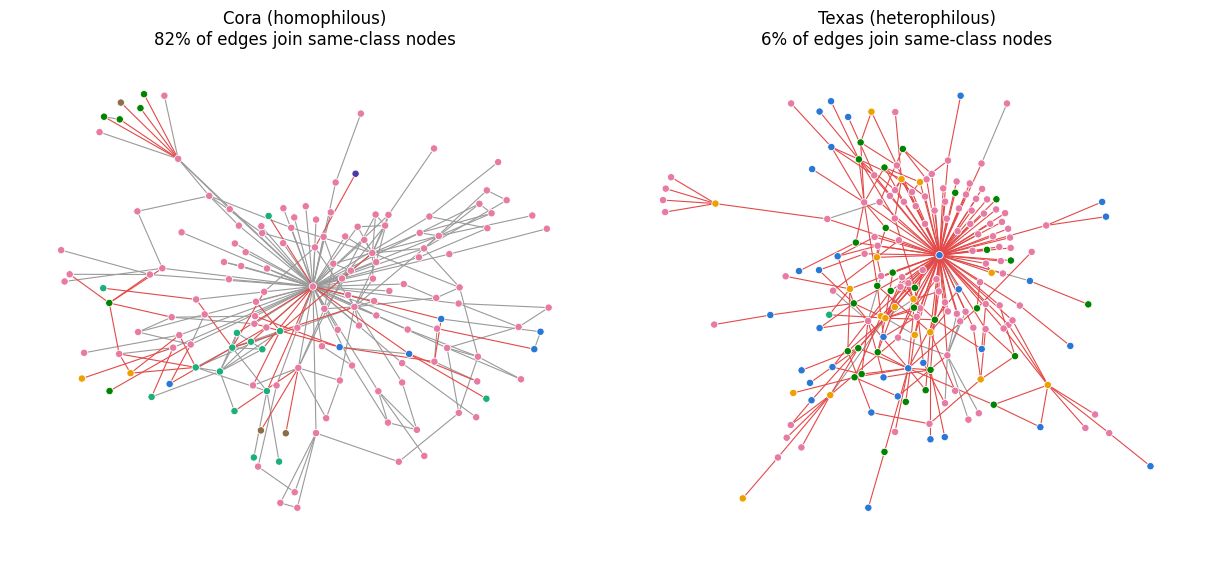

In [4]:
def bfs_subgraph(g, start=0, size=150):
    G = to_networkx(g, to_undirected=True)
    nodes = list(nx.bfs_tree(G, start))[:size]
    return G.subgraph(nodes), g.y

def draw_labeled_graph(ax, G, y, title):
    pos = nx.spring_layout(G, seed=SEED)
    same = [(u, v) for u, v in G.edges() if y[u] == y[v]]
    diff = [(u, v) for u, v in G.edges() if y[u] != y[v]]
    nx.draw_networkx_edges(G, pos, edgelist=same, ax=ax, edge_color="#9a9a9a", width=0.8)
    nx.draw_networkx_edges(G, pos, edgelist=diff, ax=ax, edge_color=CROSS_EDGE_COLOR, width=0.8)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=28, edgecolors="white", linewidths=0.6,
                           node_color=[CLASS_COLORS[int(y[n])] for n in G.nodes()])
    share = len(same) / max(G.number_of_edges(), 1)
    ax.set_title(f"{title}\n{share:.0%} of edges join same-class nodes")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
draw_labeled_graph(axes[0], *bfs_subgraph(graphs["Cora"], start=0), "Cora (homophilous)")
G_texas = to_networkx(graphs["Texas"], to_undirected=True)
G_texas = G_texas.subgraph(max(nx.connected_components(G_texas), key=len))
draw_labeled_graph(axes[1], G_texas, graphs["Texas"].y, "Texas (heterophilous)")
plt.show()

In Cora, colors form **clusters** and few edges are red. In Texas, almost every edge is red: web pages mostly link to pages of a *different* type (e.g. student pages pointing to a faculty or course hub).

## 3. Four homophily metrics

**Notation.** A graph with node set $V$ ($n = |V|$ nodes) and edge set $E$ (each undirected edge counted in both directions), labels $y$, $C$ classes, $n_k$ nodes in class $k$, degree $d_v$ and neighbors $\mathcal{N}(v)$ of node $v$.

**1. Edge homophily**: the fraction of **edges** that join two nodes of the same class.

$$h_{\text{edge}} = \frac{\left|\lbrace (u,v)\in E \,:\, y_u = y_v \rbrace\right|}{|E|}$$

**2. Node homophily**: for each node, the fraction of its neighbors in its own class, averaged over **nodes**.

$$h_{\text{node}} = \frac{1}{n}\sum_{v\in V} \frac{\left|\lbrace u\in\mathcal{N}(v) \,:\, y_u = y_v \rbrace\right|}{d_v}$$

**3. Class homophily**: the homophily $h_k$ of the edges leaving class $k$, minus the value that class size alone would give, averaged over **classes**.

$$h_{\text{class}} = \frac{1}{C-1}\sum_{k=1}^{C} \max\!\left(0,\; h_k - \frac{n_k}{n}\right)$$

**4. Adjusted homophily**: edge homophily **corrected for chance**, like Cohen's $\kappa$. Here $\bar p_k$ is the share of all edge endpoints that belong to class $k$, and $\sum_k \bar p_k^2$ is the edge homophily expected from random wiring.

$$h_{\text{adj}} = \frac{h_{\text{edge}} - \sum_{k} \bar p_k^{2}}{1 - \sum_{k} \bar p_k^{2}}, \qquad \bar p_k = \frac{1}{2|E|}\sum_{v\,:\,y_v = k} d_v$$

* $h_{\text{edge}}, h_{\text{node}}, h_{\text{class}} \in [0, 1]$, while $h_{\text{adj}} \in [-1, 1]$: **0 means "as random"** and negative means *heterophilous*.
* Edge and node homophily are dominated by **large classes**; class and adjusted homophily correct for class imbalance.

In [5]:
def edge_homophily(edge_index, y):
    src, dst = edge_index
    return (y[src] == y[dst]).float().mean().item()


def node_homophily(edge_index, y):
    src, dst = edge_index
    same = (y[src] == y[dst]).float()
    deg = degree(src, y.numel())
    same_per_node = torch.zeros_like(deg).index_add_(0, src, same)
    has_nbrs = deg > 0
    return (same_per_node[has_nbrs] / deg[has_nbrs]).mean().item()


def class_homophily(edge_index, y):
    src, dst = edge_index
    C = int(y.max()) + 1
    total = 0.0
    for k in range(C):
        from_k = y[src] == k                                    # edges leaving class k
        if from_k.any():
            h_k = (y[dst][from_k] == k).float().mean().item()   # per-class homophily
            total += max(0.0, h_k - (y == k).float().mean().item())
    return total / (C - 1)


def adjusted_homophily(edge_index, y):
    src, _ = edge_index
    C = int(y.max()) + 1
    deg = degree(src, y.numel())
    p = torch.zeros(C).index_add_(0, y, deg) / deg.sum()        # degree mass of each class
    chance = (p ** 2).sum().item()                              # expected h_edge if edges were random
    return (edge_homophily(edge_index, y) - chance) / (1 - chance)


METRICS = {"edge": edge_homophily, "node": node_homophily,
           "class": class_homophily, "adjusted": adjusted_homophily}

Quick sanity check against PyG's built-in `torch_geometric.utils.homophily`:

In [6]:
g = graphs["Cora"]
for ours, pyg in [("edge", "edge"), ("node", "node"), ("class", "edge_insensitive")]:
    print(f"{ours:>6}:  ours = {METRICS[ours](g.edge_index, g.y):.4f}   "
          f"PyG = {homophily(g.edge_index, g.y, method=pyg):.4f}")

  edge:  ours = 0.8100   PyG = 0.8100
  node:  ours = 0.8252   PyG = 0.8252
 class:  ours = 0.7657   PyG = 0.7657


## 4. Homophily of real-world graphs

In [7]:
results = pd.DataFrame({name: {m: f(g.edge_index, g.y) for m, f in METRICS.items()}
                        for name, g in graphs.items()}).T
results.index.name = "dataset"

(results.style.format("{:.3f}")
        .background_gradient(cmap="RdBu", vmin=-1, vmax=1)
        .set_caption("Homophily metrics (blue = homophilous, red = heterophilous)"))

,edge,node,class,adjusted
dataset,,,,
Cora,0.810,0.825,0.766,0.771
CiteSeer,0.736,0.717,0.627,0.671
PubMed,0.802,0.792,0.664,0.686
Texas,0.061,0.057,0.000,-0.294
Wisconsin,0.178,0.155,0.046,-0.173
Cornell,0.123,0.111,0.038,-0.220
Chameleon,0.230,0.247,0.041,0.032
Squirrel,0.222,0.217,0.031,0.007
Actor,0.217,0.220,0.006,0.003


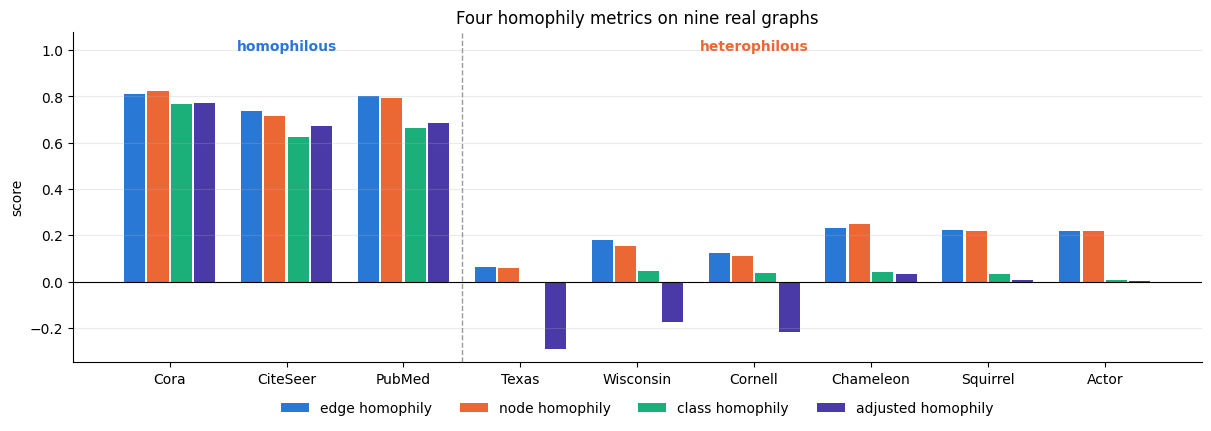

In [8]:
metric_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
x = np.arange(len(results))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
for i, (metric, color) in enumerate(zip(results.columns, metric_colors)):
    ax.bar(x + (i - 1.5) * width, results[metric], width * 0.9, color=color, label=f"{metric} homophily")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(len(HOMOPHILOUS) - 0.5, color="#9a9a9a", ls="--", lw=1)
ax.text(1, 1.0, "homophilous", ha="center", color=HOMO_COLOR, fontweight="bold")
ax.text(5, 1.0, "heterophilous", ha="center", color=HETERO_COLOR, fontweight="bold")
ax.set(xticks=x, xticklabels=results.index, ylim=(-0.35, 1.08), ylabel="score",
       title="Four homophily metrics on nine real graphs")
ax.grid(axis="x", visible=False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.show()

* On **Cora / CiteSeer / PubMed** all four metrics agree: ~70–80 % of edges are intra-class.
* On the **heterophilous** graphs, *edge* and *node* homophily report 0.05–0.25, *class* homophily is ≈ 0, and *adjusted* homophily separates two cases:
  * **Texas, Wisconsin, Cornell** are **negative**: they have *fewer* intra-class edges than random wiring would produce (true heterophily).
  * **Chameleon, Squirrel, Actor** are ≈ **0**: labels and edges are almost unrelated.

### 4.1. Class compatibility matrix

A single number hides **who connects to whom**. The compatibility matrix $H_{kl}$ is the fraction of edges leaving class $k$ that land in class $l$. A homophilous graph has a bright **diagonal**; a heterophilous one does not.

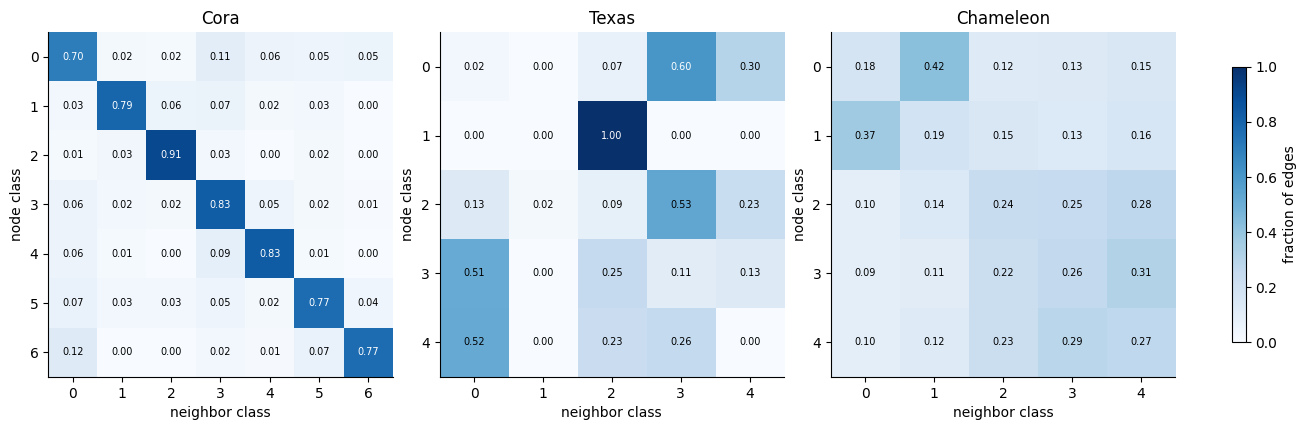

In [9]:
def compatibility_matrix(edge_index, y):
    C = int(y.max()) + 1
    H = torch.zeros(C, C)
    H.index_put_((y[edge_index[0]], y[edge_index[1]]), torch.ones(edge_index.size(1)), accumulate=True)
    return (H / H.sum(1, keepdim=True)).numpy()

with plt.rc_context({"axes.grid": False}):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    for ax, name in zip(axes, ["Cora", "Texas", "Chameleon"]):
        H = compatibility_matrix(graphs[name].edge_index, graphs[name].y)
        im = ax.imshow(H, cmap="Blues", vmin=0, vmax=1)
        for (k, l), v in np.ndenumerate(H):
            ax.text(l, k, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.55 else "black")
        ax.set(title=name, xlabel="neighbor class", ylabel="node class",
               xticks=range(len(H)), yticks=range(len(H)))
    fig.colorbar(im, ax=axes, shrink=0.8, label="fraction of edges")
    plt.show()

Cora is almost diagonal. **Texas** has a near-empty diagonal: the bright cells are *off* it (class 0 ↔ class 3, class 1 → class 2), so knowing a neighbor's class is still very informative, it just predicts a *different* class. **Chameleon** is spread out, except that classes 0 and 1 link mostly to each other.

### 4.2. Node homophily is a distribution, not a number

$h_{node}$ is an **average** over nodes. Plotting the per-node values shows that even a "homophilous" graph contains strongly heterophilous nodes, and vice versa.

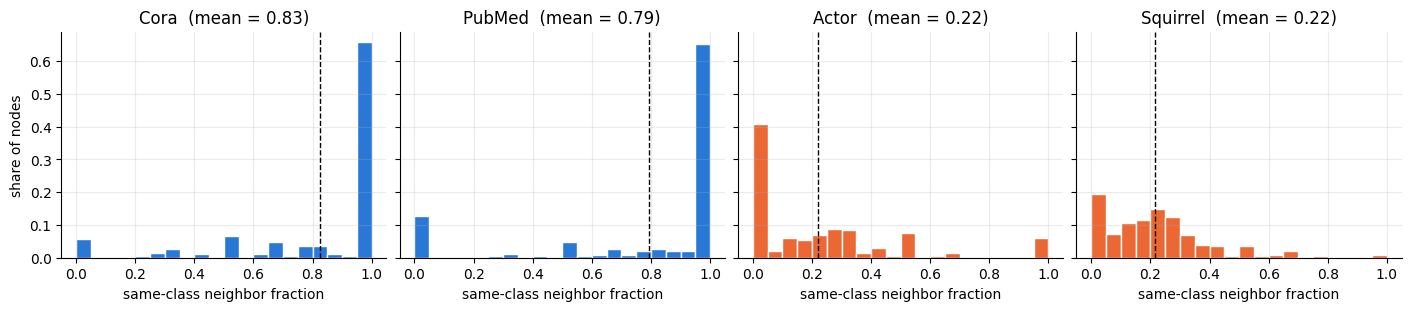

In [10]:
def per_node_homophily(edge_index, y):
    src, dst = edge_index
    deg = degree(src, y.numel())
    same = torch.zeros_like(deg).index_add_(0, src, (y[src] == y[dst]).float())
    return (same[deg > 0] / deg[deg > 0]).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True, constrained_layout=True)
for ax, name in zip(axes, ["Cora", "PubMed", "Actor", "Squirrel"]):
    values = per_node_homophily(graphs[name].edge_index, graphs[name].y)
    color = HOMO_COLOR if name in HOMOPHILOUS else HETERO_COLOR
    ax.hist(values, bins=20, range=(0, 1), color=color, edgecolor="white",
            weights=np.ones_like(values) / len(values))
    ax.axvline(values.mean(), color="black", ls="--", lw=1)
    ax.set(title=f"{name}  (mean = {values.mean():.2f})", xlabel="same-class neighbor fraction")
axes[0].set_ylabel("share of nodes")
plt.show()

## 5. Why do we need *adjusted* homophily?

Edge homophily has a hidden baseline: if one class owns most of the edges, **random** edges are often intra-class too. A quick test: **shuffle the labels** (keeping class sizes) so that labels and structure are unrelated. A good metric should then read ≈ 0.

In [11]:
g = torch.Generator().manual_seed(SEED)
rows = []
for name, graph in graphs.items():
    y_random = graph.y[torch.randperm(graph.num_nodes, generator=g)]
    rows.append({"dataset": name,
                 **{f"{m} (shuffled)": f(graph.edge_index, y_random) for m, f in METRICS.items()}})

(pd.DataFrame(rows).set_index("dataset").style.format("{:.3f}")
   .background_gradient(cmap="RdBu", vmin=-1, vmax=1)
   .set_caption("Homophily with random labels — the ideal value is 0"))

,edge (shuffled),node (shuffled),class (shuffled),adjusted (shuffled)
dataset,,,,
Cora,0.178,0.177,0.004,0.001
CiteSeer,0.183,0.188,0.013,0.006
PubMed,0.354,0.355,0.001,-0.002
Texas,0.297,0.307,0.023,-0.069
Wisconsin,0.327,0.342,0.028,-0.019
Cornell,0.249,0.244,0.026,-0.030
Chameleon,0.204,0.202,0.006,0.002
Squirrel,0.200,0.202,0.002,-0.001
Actor,0.216,0.211,0.008,0.002


With random labels, edge and node homophily still report **0.18–0.35**: that is their *chance level*, and it changes with the number and size of classes (PubMed has only 3 classes, so it is highest). Compare with Section 4: Actor's real edge homophily (0.217) is the **same** as its random value (0.216), so its 0.22 carries no signal at all. Class homophily and, above all, **adjusted homophily stay ≈ 0**, which makes them comparable **across** datasets.

## 6. Why it matters: GCN vs. MLP

A GCN averages a node's features with its neighbors'. That helps when neighbors share the label and hurts when they do not. An **MLP** ignores the graph completely. We train both on the same 60 / 20 / 20 random split, repeat over **10 runs** (a new split and initialization each run), and report **mean ± std** of the test accuracy and of the gain

$$\Delta = \text{Acc}_{\text{GCN}} - \text{Acc}_{\text{MLP}}\qquad(\Delta > 0:\ \text{the graph helps}).$$

In [12]:
class Net(torch.nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, use_graph=True):
        super().__init__()
        Layer = GCNConv if use_graph else (lambda i, o: torch.nn.Linear(i, o))
        self.layer1, self.layer2, self.use_graph = Layer(in_dim, hidden), Layer(hidden, out_dim), use_graph

    def forward(self, x, edge_index):
        args = (edge_index,) if self.use_graph else ()
        x = F.dropout(F.relu(self.layer1(x, *args)), p=0.5, training=self.training)
        return self.layer2(x, *args)


def train_and_test(graph, use_graph, seed, epochs=200):
    torch.manual_seed(seed)                                     # same seed -> same split for GCN and MLP
    perm = torch.randperm(graph.num_nodes)
    n_train, n_val = int(0.6 * graph.num_nodes), int(0.2 * graph.num_nodes)
    train, val, test = perm[:n_train], perm[n_train:n_train + n_val], perm[n_train + n_val:]
    graph = graph.to(DEVICE)
    model = Net(graph.num_features, int(graph.y.max()) + 1, use_graph=use_graph).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    best_val = test_acc = 0
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        F.cross_entropy(model(graph.x, graph.edge_index)[train], graph.y[train]).backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(graph.x, graph.edge_index).argmax(1)
        acc = lambda idx: (pred[idx] == graph.y[idx]).float().mean().item()
        if acc(val) >= best_val:
            best_val, test_acc = acc(val), acc(test)
    return test_acc


NUM_RUNS = 10
runs = pd.DataFrame([{"dataset": name, "run": s,
                      "MLP": train_and_test(g, False, s), "GCN": train_and_test(g, True, s)}
                     for name, g in graphs.items() for s in range(NUM_RUNS)])
runs["Δ"] = runs["GCN"] - runs["MLP"]                          # paired: same split in each run

summary = runs.groupby("dataset", sort=False)[["MLP", "GCN", "Δ"]].agg(["mean", "std"])
fmt = lambda col, sign="": [f"{m:{sign}.3f} ± {s:.3f}" for m, s in summary[col].itertuples(index=False)]
table = pd.DataFrame({"MLP accuracy": fmt("MLP"), "GCN accuracy": fmt("GCN"),
                      "Δ (GCN vs. MLP)": fmt("Δ", "+")}, index=summary.index)
table

,MLP accuracy,GCN accuracy,Δ (GCN vs. MLP)
dataset,,,
Cora,0.767 ± 0.020,0.879 ± 0.013,+0.112 ± 0.017
CiteSeer,0.724 ± 0.012,0.773 ± 0.009,+0.049 ± 0.015
PubMed,0.871 ± 0.006,0.865 ± 0.005,-0.005 ± 0.004
Texas,0.779 ± 0.053,0.645 ± 0.033,-0.134 ± 0.061
Wisconsin,0.871 ± 0.045,0.610 ± 0.067,-0.261 ± 0.081
Cornell,0.774 ± 0.050,0.558 ± 0.071,-0.216 ± 0.067
Chameleon,0.480 ± 0.033,0.563 ± 0.016,+0.083 ± 0.028
Squirrel,0.305 ± 0.009,0.346 ± 0.023,+0.041 ± 0.024
Actor,0.379 ± 0.010,0.302 ± 0.011,-0.078 ± 0.014


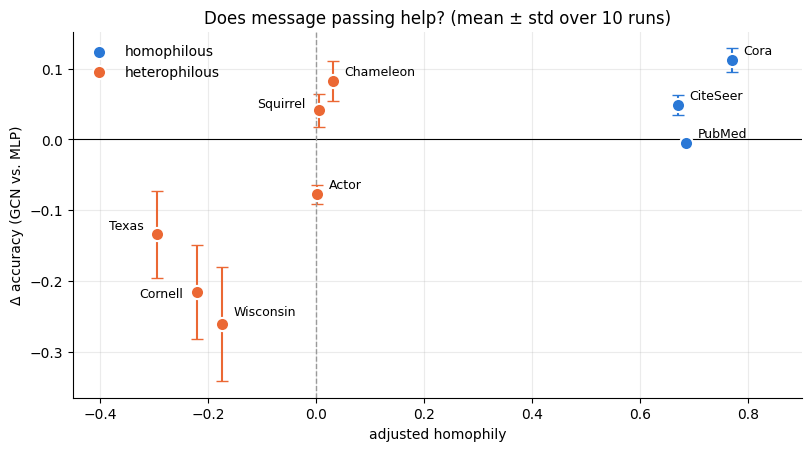

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
for group, names, color in [("homophilous", HOMOPHILOUS, HOMO_COLOR),
                            ("heterophilous", [n for n in graphs if n not in HOMOPHILOUS], HETERO_COLOR)]:
    h, delta = results.loc[names, "adjusted"], summary.loc[names, ("Δ", "mean")]
    ax.errorbar(h, delta, yerr=summary.loc[names, ("Δ", "std")], fmt="none", color=color,
                elinewidth=1.5, capsize=4, zorder=2)
    ax.scatter(h, delta, s=90, color=color, edgecolors="white", linewidths=1.5, label=group, zorder=3)
for name in graphs:
    h, delta = results.loc[name, "adjusted"], summary.loc[name, ("Δ", "mean")]
    dx, dy = {"Cornell": (-10, -4), "Wisconsin": (8, 6), "Texas": (-10, 4), "Squirrel": (-10, 2)}.get(name, (8, 4))
    ax.annotate(name, (h, delta), xytext=(dx, dy), textcoords="offset points", fontsize=9,
                ha="right" if dx < 0 else "left")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="#9a9a9a", ls="--", lw=1)
ax.set(xlabel="adjusted homophily", ylabel="Δ accuracy (GCN vs. MLP)", xlim=(-0.45, 0.9),
       title=f"Does message passing help? (mean ± std over {NUM_RUNS} runs)")
ax.legend(loc="upper left", frameon=False)
plt.show()

* **Homophilous** graphs (blue): GCN matches or beats the MLP (Δ = +0.11 on Cora, far larger than its std of 0.02).
* **Negative** adjusted homophily (Texas, Wisconsin, Cornell): averaging mixes in the *wrong* class, and GCN is worse than a model that ignores the graph (Δ from −0.13 to −0.26). The std is larger here because these graphs have only ~180–250 nodes, so each test set is tiny, but Δ stays clearly below 0.
* **Chameleon and Squirrel** are the interesting exception: adjusted homophily ≈ 0, yet GCN helps. Their compatibility matrices are not uniform, and their node features are weak, so the neighborhood still adds information. Homophily is a strong hint, **not** the whole story.

## 7. Takeaways

* **Homophily** = edges connect similar labels; **heterophily** = edges connect different labels. Real graphs span the whole range.
* **Class** homophily removes the class-size effect per class; **adjusted** homophily removes it for the whole graph and has a clear zero point, so it is the safest single number for comparing datasets.
* The **compatibility matrix** shows *which* classes connect, which a single score cannot.
* Plain GNNs such as GCN gain over an MLP on homophilous graphs and can **lose** on heterophilous ones. Heterophily-aware models (H2GCN, GPR-GNN, FAGCN, …) separate ego and neighbor information or learn *signed* aggregation to cope with this.

### Further reading
- McPherson, Smith-Lovin & Cook. *Birds of a Feather: Homophily in Social Networks.* Annual Review of Sociology, 2001.
- Pei et al. *Geom-GCN: Geometric Graph Convolutional Networks.* ICLR 2020 (node homophily; WebKB, Chameleon, Squirrel, Actor splits).
- Zhu et al. *Beyond Homophily in Graph Neural Networks: Current Limitations and Effective Designs.* NeurIPS 2020 (edge homophily, H2GCN).
- Lim et al. *Large Scale Learning on Non-Homophilous Graphs: New Benchmarks and Strong Simple Methods.* NeurIPS 2021 (class homophily).
- Platonov et al. *Characterizing Graph Datasets for Node Classification: Homophily–Heterophily Dichotomy and Beyond.* NeurIPS 2023 (adjusted homophily).